# Trumpet plot

Trumpet plots were introduced in the research article

Corte L, Liou L, O'Reilly PF, García-González J. Trumpet plots: visualizing the relationship between allele frequency and effect size in genetic association studies. *GigaByte*. 2023 Sep 1;2023:gigabyte89. doi: https://doi.org/10.46471/gigabyte.89. PMID: 37711278; PMCID: PMC10498096.

and its goal is to visualize effect size of risk variants across the allele frequency spectrum.

In [1]:
import sys
import os

import pandas as pd

# add parent directory to path
library_path = os.path.abspath('..')
if library_path not in sys.path:
    sys.path.append(library_path)

from ideal_genom.visualizations.plots import trumpet_draw
from ideal_genom.core.get_examples import get_trumpet_binary_example

The first example corresponds to a trumpet plot for a binary trait: Parkinson's disease. We are going to use the summary statistics provided in the study:

Park, K.W., Ryu, HS., Shin, E. et al. Ethnicity- and sex-specific genome wide association study on Parkinson’s disease. *npj Parkinsons Dis.* **9**, 141 (2023). https://doi.org/10.1038/s41531-023-00580-3

In [2]:
file_path = get_trumpet_binary_example()

2026-01-26 13:45:19,266 - INFO - Downloading file: http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST90278001-GCST90279000/GCST90278092/harmonised/GCST90278092.h.tsv.gz to /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/GCST90278092.h.tsv.gz
2026-01-26 13:45:25,330 - INFO - Decompressing file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/GCST90278092.h.tsv.gz


Decompressed: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/GCST90278092.h.tsv
Removed original .gz file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/GCST90278092.h.tsv.gz


In [3]:
chunk_size = 2000

filtered_chunks=[]

filepath = file_path.as_posix()

for chunk in pd.read_csv(filepath, sep=r'\s+', engine='python', chunksize=chunk_size):
    
    filtered_chunk = chunk[chunk['p_value'] < 5e-4].reset_index(drop=True)
    filtered_chunks.append(filtered_chunk)

df_gwas = pd.concat(filtered_chunks, ignore_index=True)

In [4]:
df_gwas['minor_allele_frequency'] = df_gwas['effect_allele_frequency'].apply(lambda x: min(x, 1-x))

2026-01-26 13:45:51,602 - INFO - Prevalence not provided. Infering from the number of cases and controls: 0.17
2026-01-26 13:45:51,626 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:45:52,138 - INFO -  -Extracting eaf-beta combinations with power = 0.2...
2026-01-26 13:45:52,144 - INFO -  -Found 1961 eaf-beta combinations with power >= 0.2 and columns: Index(['eaf', 'beta', 'power'], dtype='object')
2026-01-26 13:45:52,160 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:45:52,709 - INFO -  -Extracting eaf-beta combinations with power = 0.4...
2026-01-26 13:45:52,715 - INFO -  -Found 1950 eaf-beta combinations with power >= 0.4 and columns: Index(['eaf', 'beta', 'power'], dtype='object')
2026-01-26 13:45:52,723 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:45:53,249 - INFO -  -Extracting eaf-beta combinations with power = 0.6...
2026-01-26 13:45:53,254 - INFO -  -Found 1940 eaf-beta combinations with power >= 0.6 and columns: Index(['eaf', 'beta', 'power'], dtype='object')


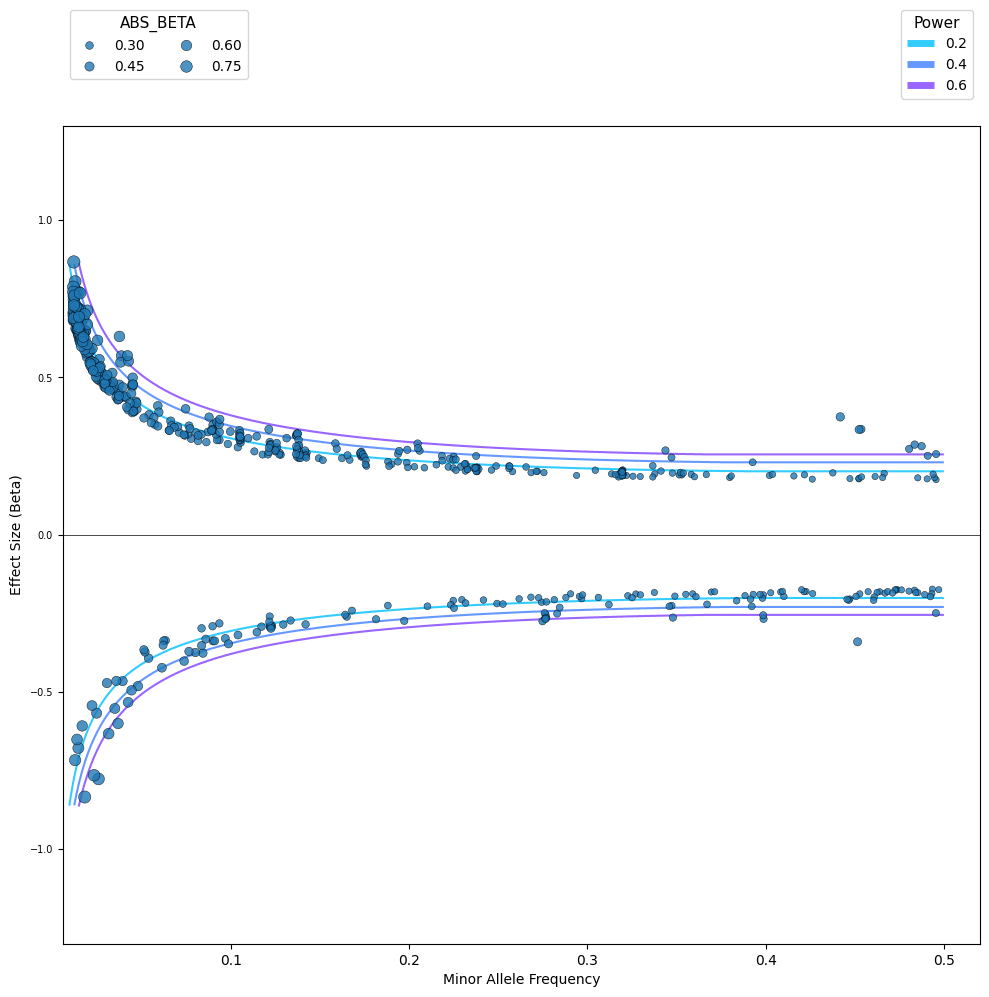

True

In [5]:
trumpet_draw(
    df_gwas    =df_gwas, 
    df_freq    =None, 
    plot_dir   = file_path.parent.as_posix(), 
    snp_col    ="rsid", 
    chr_col    ='chromosome', 
    pos_col    ='base_pair_location',
    maf_col    ='minor_allele_frequency', 
    beta_col   ='beta', 
    power_ts   =[0.2,0.4,0.6], 
    n_case=1050,
    n_control=5000,
    sample_size=6050,
    sample_size_strategy='median', 
    p_col      ='p_value', 
    mode       ='binary', 
    p_filter   =None, 
    save_name  ='trumpet_plot_bin.png',
)

In the cited study, there is not information about top hits so, to try the highlighting, let us check the SNPs with lowest $p$-value.

In [6]:
to_hightlight = df_gwas[df_gwas['p_value'] < 5e-7]['rsid'].tolist()

2026-01-26 13:46:01,073 - INFO - Prevalence not provided. Infering from the number of cases and controls: 0.17
2026-01-26 13:46:01,088 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:46:01,580 - INFO -  -Extracting eaf-beta combinations with power = 0.2...
2026-01-26 13:46:01,586 - INFO -  -Found 1961 eaf-beta combinations with power >= 0.2 and columns: Index(['eaf', 'beta', 'power'], dtype='object')
2026-01-26 13:46:01,592 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:46:02,125 - INFO -  -Extracting eaf-beta combinations with power = 0.4...
2026-01-26 13:46:02,131 - INFO -  -Found 1950 eaf-beta combinations with power >= 0.4 and columns: Index(['eaf', 'beta', 'power'], dtype='object')
2026-01-26 13:46:02,139 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:46:02,689 - INFO -  -Extracting eaf-beta combinations with power = 0.6...
2026-01-26 13:46:02,695 - INFO -  -Found 1940 eaf-beta combinations with power >= 0.6 and columns: Index(['eaf', 'beta', 'power'], dtype='object')


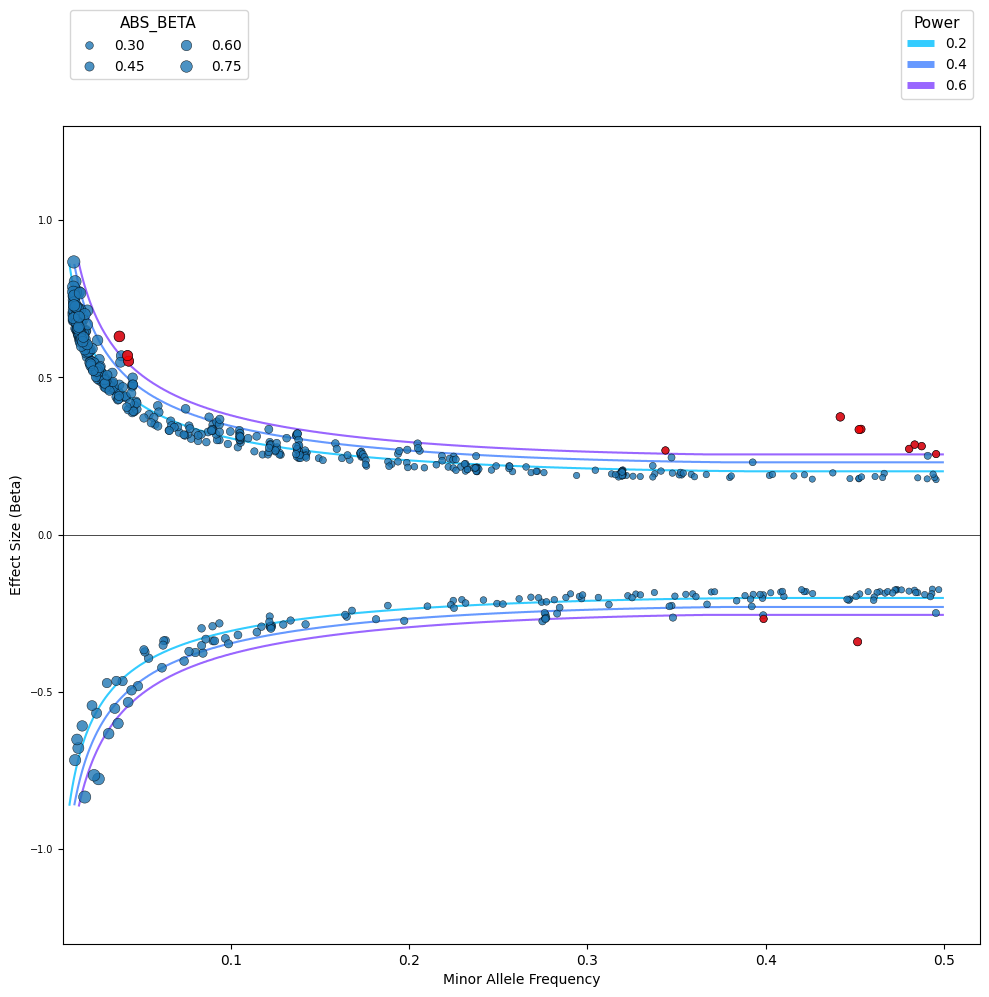

True

In [7]:
trumpet_draw(
    df_gwas    =df_gwas, 
    df_freq    =None, 
    plot_dir   = file_path.parent.as_posix(), 
    snp_col    ="rsid", 
    chr_col    ='chromosome', 
    pos_col    ='base_pair_location',
    maf_col    ='minor_allele_frequency', 
    beta_col   ='beta', 
    power_ts   =[0.2,0.4,0.6], 
    n_case=1050,
    n_control=5000,
    sample_size=6050,
    sample_size_strategy='median', 
    p_col      ='p_value', 
    mode       ='binary', 
    p_filter   =None, 
    save_name  ='trumpet_plot_bin_hlited.png',
    to_highlight=to_hightlight
)

In [8]:
to_annotate = df_gwas[df_gwas['p_value'] < 5e-7][['rsid']].reset_index(drop=True)

To annotate the plot, it quite easy, just take into account that in this example the build is 37.

2026-01-26 13:46:10,816 - INFO - Prevalence not provided. Infering from the number of cases and controls: 0.17
2026-01-26 13:46:10,820 - INFO - Filtering GWAS dataframe with p-value < 5e-05
2026-01-26 13:46:10,820 - INFO - Number of SNPs in filtered GWAS dataframe: 110
2026-01-26 13:46:10,837 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:46:11,345 - INFO -  -Extracting eaf-beta combinations with power = 0.2...
2026-01-26 13:46:11,351 - INFO -  -Found 1961 eaf-beta combinations with power >= 0.2 and columns: Index(['eaf', 'beta', 'power'], dtype='object')
2026-01-26 13:46:11,359 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:46:11,898 - INFO -  -Extracting eaf-beta combinations with power = 0.4...
2026-01-26 13:46:11,904 - INFO -  -Found 1950 eaf-beta combinations with power >= 0.4 and columns: Index(['eaf', 'beta', 'power'], dtype='object')
2026-01-26 13:46:11,912 - INFO -  -GRR is approximated using OR. For prevalence < 10%, GRR is very similar to OR....


 -Updating eaf-beta matrix...


2026-01-26 13:46:12,453 - INFO -  -Extracting eaf-beta combinations with power = 0.6...
2026-01-26 13:46:12,459 - INFO -  -Found 1940 eaf-beta combinations with power >= 0.6 and columns: Index(['eaf', 'beta', 'power'], dtype='object')
2026-01-26 13:46:12,581 - INFO - Annotating 13 SNPs with from ensembl with build 37...
2026-01-26 13:46:12,582 - INFO - Starting to annotate variants with nearest gene name(s)...
2026-01-26 13:46:12,583 - INFO -  -Using 37 as genome build
2026-01-26 13:46:12,583 - INFO - is_gtf_path set to False
2026-01-26 13:46:12,584 - INFO -  -Using ensembl as source for gene annotation
2026-01-26 13:46:12,585 - INFO -  -Assigning Gene name using Ensembl GRCh37 for protein coding genes
2026-01-26 13:46:12,585 - INFO -  -Downloading Ensembl GRCh37 GTF file
2026-01-26 13:46:12,988 - INFO - Latest GTF file: Homo_sapiens.GRCh37.87.chr.gtf.gz
2026-01-26 13:46:12,989 - INFO - Download URL: https://ftp.ensembl.org/pub/grch37/release-115/gtf/homo_sapiens/Homo_sapiens.GRCh37.87

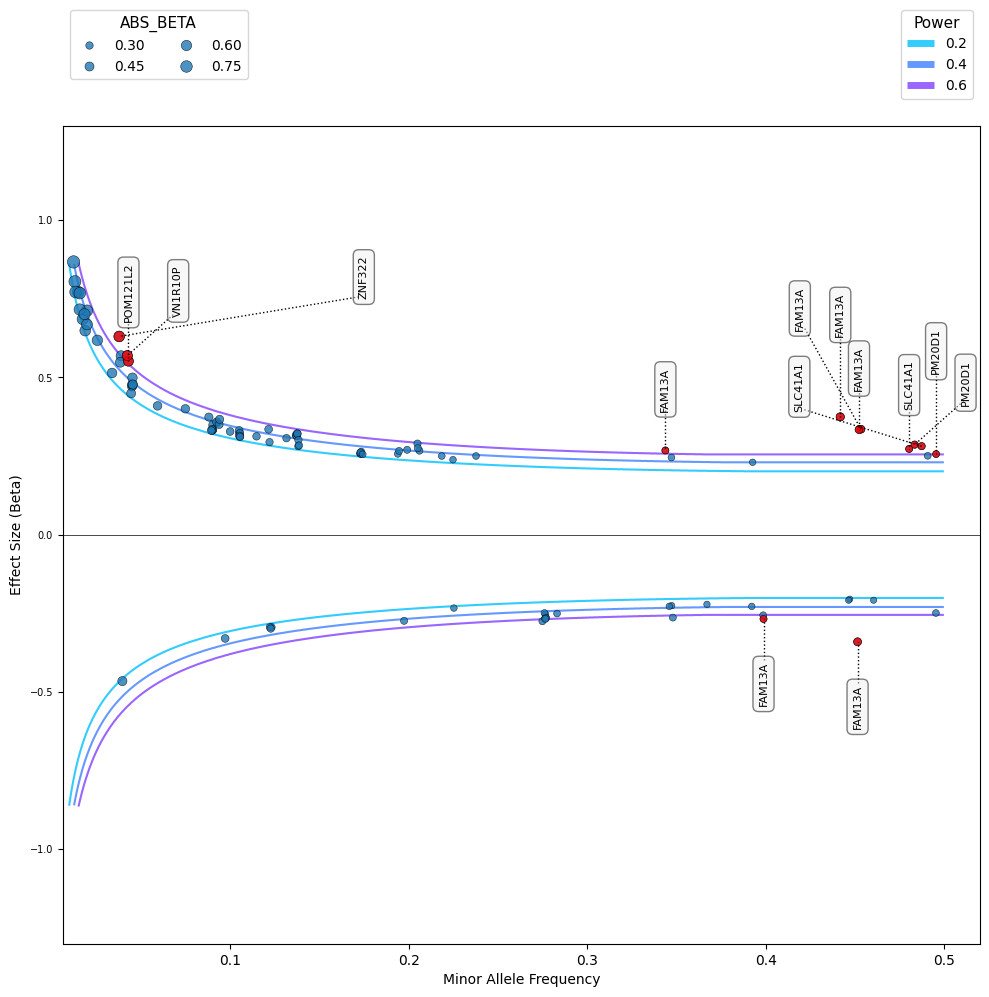

True

In [9]:
trumpet_draw(
    df_gwas    =df_gwas, 
    df_freq    =None, 
    plot_dir   = file_path.parent.as_posix(), 
    snp_col    ="rsid", 
    chr_col    ='chromosome', 
    pos_col    ='base_pair_location',
    maf_col    ='minor_allele_frequency', 
    beta_col   ='beta', 
    power_ts   =[0.2,0.4,0.6], 
    n_case=1050,
    n_control=5000,
    sample_size=6050,
    sample_size_strategy='median', 
    p_col      ='p_value', 
    mode       ='binary', 
    p_filter   =5e-5, 
    save_name  ='trumpet_plot_bin_anno.png',
    to_highlight=to_hightlight,
    to_annotate=to_annotate,
    build='37'
)